In [1]:
import pandas as pd

# Leer el CSV local. Ajusta la ruta según dónde lo guardaste.
df = pd.read_csv("data/partidos_filtrados.csv")

# Convertir 'date' a fecha real otra vez.
# Al guardar y releer, la fecha vuelve a ser TEXTO, así que la reconvertimos.
df["date"] = pd.to_datetime(df["date"])
df.tail(10)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
1523,2026-06-30,Mexico,Ecuador,NaN,NaN,FIFA World Cup,Mexico City,Mexico,False
1524,2026-07-01,England,DR Congo,NaN,NaN,FIFA World Cup,Atlanta,United States,True
1525,2026-07-01,Belgium,Senegal,NaN,NaN,FIFA World Cup,Seattle,United States,True
1526,2026-07-01,United States,Bosnia and Herzegovina,NaN,NaN,FIFA World Cup,Santa Clara,United States,False
1527,2026-07-02,Spain,Austria,NaN,NaN,FIFA World Cup,Inglewood,United States,True
1528,2026-07-02,Portugal,Croatia,NaN,NaN,FIFA World Cup,Toronto,Canada,True
1529,2026-07-02,Switzerland,Algeria,NaN,NaN,FIFA World Cup,Vancouver,Canada,True
1530,2026-07-03,Australia,Egypt,NaN,NaN,FIFA World Cup,Arlington,United States,True
1531,2026-07-03,Argentina,Cape Verde,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
1532,2026-07-03,Colombia,Ghana,NaN,NaN,FIFA World Cup,Kansas City,United States,True


In [2]:
df = df.dropna(subset=["home_score", "away_score"])

# Y ahora que no hay vacíos, conviene asegurar que son enteros
df["home_score"] = df["home_score"].astype(int)
df["away_score"] = df["away_score"].astype(int)

print(df.shape)

(1518, 9)


In [3]:
# 1. El diccionario de rankings FIFA el 27 de junio de 2026
# Puntajes Elo FIFA (transcritos de las capturas).
# Nombres EXACTOS como aparecen en el dataset (results.csv).
elo_fifa = {
    "Argentina": 1907.40,
    "France": 1906.84,
    "Spain": 1879.58,
    "England": 1840.46,
    "Brazil": 1804.92,
    "Morocco": 1776.40,
    "Netherlands": 1775.50,
    "Portugal": 1764.86,
    "Mexico": 1736.01,
    "Belgium": 1735.41,
    "Colombia": 1729.30,
    "Germany": 1726.22,
    "Croatia": 1723.05,
    "Italy": 1704.73,
    "United States": 1677.17,
    "Switzerland": 1676.00,
    "Japan": 1673.68,
    "Senegal": 1653.43,
    "Uruguay": 1634.70,
    "Denmark": 1619.47,
    "Iran": 1609.85,
    "Austria": 1598.82,
    "Norway": 1594.04,
    "Ecuador": 1592.59,
    "Nigeria": 1585.02,
    "Egypt": 1584.71,
    "Turkey": 1582.54,
    "Australia": 1581.35,
    "Algeria": 1576.80,
    "Canada": 1571.34,
    "Ivory Coast": 1565.47,
    "South Korea": 1558.72,
    "Ukraine": 1549.29,
    "Paraguay": 1529.98,
    "Russia": 1529.60,
    "Poland": 1526.18,
    "Sweden": 1525.58,
    "Wales": 1516.95,
    "Hungary": 1506.39,
    "Serbia": 1502.13,
    "DR Congo": 1495.48,
    "Scotland": 1491.22,
    "Cameroon": 1481.24,
    "Panama": 1478.41,
    "Slovakia": 1473.66,
    "Greece": 1473.19,
    "Venezuela": 1469.18,
    "Czech Republic": 1467.26,
    "Chile": 1458.20,
    "Peru": 1457.69,
    "Costa Rica": 1456.03,
    "Romania": 1455.89,
    "Mali": 1455.59,
    "South Africa": 1451.24,
    "Republic of Ireland": 1441.10,
    "Slovenia": 1441.09,
    "Tunisia": 1426.58,
    "Saudi Arabia": 1425.52,
    "Qatar": 1411.06,
    "Uzbekistan": 1409.73,
    "Bosnia and Herzegovina": 1408.93,
    "Burkina Faso": 1406.99,
    "Iraq": 1404.17,
    "Cape Verde": 1402.97,
    "Ghana": 1387.00,
    "Honduras": 1378.97,
    "Albania": 1376.03,
    "United Arab Emirates": 1370.47,
    "North Macedonia": 1369.16,
    "Northern Ireland": 1365.30,
    "Jamaica": 1357.84,
    "Georgia": 1355.26,
    "Jordan": 1350.41,
    "Iceland": 1342.77,
    "Finland": 1341.92,
    "Israel": 1333.90,
    "Bolivia": 1326.00,
    "Kosovo": 1319.12,
    "Oman": 1306.90,
    "Montenegro": 1301.98,
    "Guinea": 1295.60,
    "Curaçao": 1285.64,
    "Syria": 1283.05,
    "Gabon": 1272.51,
    "Bulgaria": 1271.68,
    "New Zealand": 1269.80,
    "Angola": 1265.58,
    "Haiti": 1264.58,
    "Uganda": 1264.09,
    "Zambia": 1255.82,
    "China": 1254.81,
    "Bahrain": 1254.41,
    "Benin": 1252.17,
    "Thailand": 1250.80,
    "Palestine": 1243.71,
    "Belarus": 1242.88,
    "Guatemala": 1238.74,
    "Luxembourg": 1232.82,
    "Vietnam": 1225.68,
    "El Salvador": 1225.34,
    "Tajikistan": 1224.19,
    "Trinidad and Tobago": 1219.59,
    "Mozambique": 1218.62,
    "Madagascar": 1202.69,
    "Equatorial Guinea": 1195.20,
    "Kyrgyzstan": 1192.16,
    "Armenia": 1189.63,
    "Comoros": 1187.91,
    "Kenya": 1185.08,
    "Libya": 1182.08,
    "Kazakhstan": 1180.78,
    "Tanzania": 1180.27,
    "Mauritania": 1176.68,
    "Niger": 1175.33,
    "Lebanon": 1172.22,
    "Gambia": 1159.64,
    "Sudan": 1157.22,
    "Indonesia": 1157.14,
    "Togo": 1152.76,
    "North Korea": 1151.05,
    "Namibia": 1148.84,
    "Sierra Leone": 1147.56,
    "Faroe Islands": 1136.59,
    "Cyprus": 1133.25,
    "Suriname": 1132.43,
    "Azerbaijan": 1132.00,
    "Estonia": 1130.64,
    "Rwanda": 1126.62,
    "Malawi": 1122.05,
    "Zimbabwe": 1119.78,
    "Nicaragua": 1114.63,
    "Guinea-Bissau": 1108.38,
    "Kuwait": 1106.47,
    "Congo": 1105.96,
    "Philippines": 1100.95,
    "Malaysia": 1086.22,
    "Latvia": 1085.66,
    "India": 1084.93,
    "Central African Republic": 1080.82,
    "Liberia": 1080.44,
    "Guadeloupe": 1080,
    "Turkmenistan": 1078.65,
    "Burundi": 1078.01,
    "Ethiopia": 1077.52,
    "Dominican Republic": 1076.50,
    "Yemen": 1065.24,
    "Lesotho": 1064.29,
    "Botswana": 1063.63,
    "Singapore": 1057.95,
    "Lithuania": 1056.85,
    "Guyana": 1049.32,
    "New Caledonia": 1036.95,
    "Saint Kitts and Nevis": 1036.33,
    "Solomon Islands": 1031.89,
    "Puerto Rico": 1024.30,
    "Fiji": 1024.17,
    "Hong Kong": 1024.16,
    "Tahiti": 1019.04,
    "Myanmar": 1010.91,
    "Moldova": 1008.24,
    "Vanuatu": 1002.53,
    "Malta": 992.79,
    "Antigua and Barbuda": 986.58,
    "Grenada": 981.82,
    "Cuba": 981.42,
    "Eswatini": 979.01,
    "Saint Lucia": 976.71,
    "Bermuda": 975.05,
    "Papua New Guinea": 974.90,
    "South Sudan": 970.94,
    "Saint Vincent and the Grenadines": 968.27,
    "Afghanistan": 968.07,
    "Andorra": 946.43,
    "Maldives": 943.92,
    "Chinese Taipei": 923.78,
    "Cambodia": 922.32,
    "Montserrat": 916.75,
    "Nepal": 914.54,
    "Mauritius": 911.49,
    "Barbados": 909.89,
    "Belize": 907.00,
    "Bangladesh": 902.93,
    "Dominica": 897.69,
    "Chad": 896.85,
    "Eritrea": 887.06,
    "Laos": 885.03,
    "Cook Islands": 877.53,
    "Sri Lanka": 876.86,
    "Samoa": 876.41,
    "Aruba": 875.61,
    "Mongolia": 874.47,
    "American Samoa": 871.61,
    "Bhutan": 870.81,
    "Macau": 858.03,
    "Brunei": 857.73,
    "São Tomé and Príncipe": 855.44,
    "Djibouti": 853.58,
    "Cayman Islands": 850.06,
    "Pakistan": 840.28,
    "Somalia": 839.17,
    "Tonga": 835.64,
    "Timor-Leste": 831.00,
    "Gibraltar": 820.26,
    "Guam": 819.54,
    "Seychelles": 804.16,
    "Turks and Caicos Islands": 803.98,
    "Liechtenstein": 797.70,
    "Bahamas": 786.82,
    "United States Virgin Islands": 779.76,
    "British Virgin Islands": 777.41,
    "Anguilla": 760.25,
    "San Marino": 721.20,
}

# Aplicar al DataFrame
df["elo_local"]     = df["home_team"].map(elo_fifa)
df["elo_visitante"] = df["away_team"].map(elo_fifa)

# VERIFICACIÓN CRÍTICA: ¿quedó algún equipo sin Elo?
sin_elo_local = df[df["elo_local"].isna()]["home_team"].unique()
sin_elo_visit = df[df["elo_visitante"].isna()]["away_team"].unique()
print("Equipos sin Elo (local):", sin_elo_local)
print("Equipos sin Elo (visitante):", sin_elo_visit)

Equipos sin Elo (local): []
Equipos sin Elo (visitante): []


In [4]:
df.tail()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,elo_local,elo_visitante
1513,2026-06-27,Colombia,Portugal,0,0,FIFA World Cup,Miami Gardens,United States,True,1729.30,1764.86
1514,2026-06-27,DR Congo,Uzbekistan,3,1,FIFA World Cup,Atlanta,United States,True,1495.48,1409.73
1515,2026-06-27,Panama,England,0,2,FIFA World Cup,East Rutherford,United States,True,1478.41,1840.46
1516,2026-06-27,Croatia,Ghana,2,1,FIFA World Cup,Philadelphia,United States,True,1723.05,1387.00
1517,2026-06-28,South Africa,Canada,0,1,FIFA World Cup,Inglewood,United States,True,1451.24,1571.34


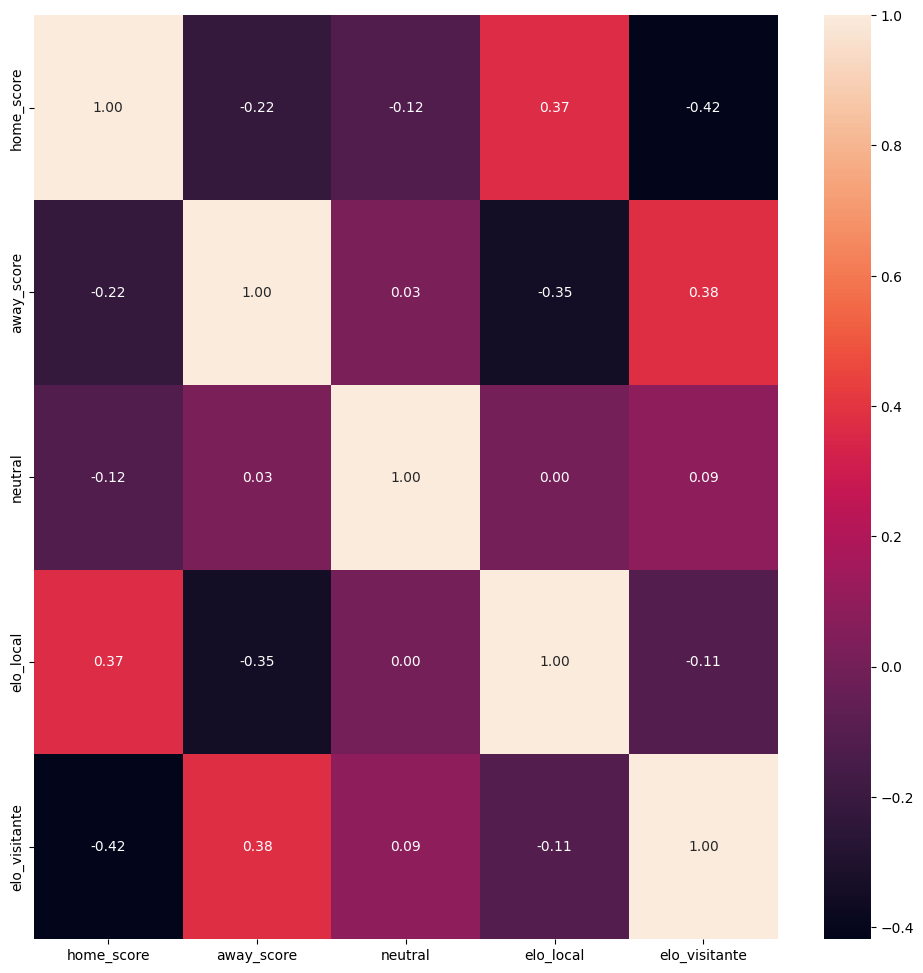

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import warnings
warnings.filterwarnings('ignore')
plt.figure(figsize = (12, 12))
sb.heatmap(df.corr(numeric_only = True), annot = True, fmt = '0.2f')
plt.show()

In [6]:
# --- MEDIA TABLA 1: perspectiva del LOCAL ---
# Seleccionamos las columnas relevantes y las renombramos a la forma "yo/rival".
local = df[["date", "home_team", "away_team", "home_score", "elo_local", "elo_visitante", "neutral"]].copy()
local = local.rename(columns={
    "home_team": "equipo",
    "away_team": "rival",
    "home_score": "goles_metidos",
    "elo_local": "mi_elo",
    "elo_visitante": "elo_rival",
})
# El local solo tiene ventaja si NO es cancha neutral.
local["es_local"] = (~local["neutral"]).astype(int)

# --- MEDIA TABLA 2: perspectiva del VISITANTE ---
# Mismo proceso pero cruzado: el visitante es ahora "equipo".
visitante = df[["date", "home_team", "away_team", "away_score", "elo_local", "elo_visitante", "neutral"]].copy()
visitante = visitante.rename(columns={
    "away_team": "equipo",        # TODO: ¿qué columna es el equipo desde la perspectiva visitante?
    "home_team": "rival",         # TODO: ¿y su rival?
    "away_score": "goles_metidos",
    "elo_visitante": "mi_elo",        # TODO: el elo del visitante
    "elo_local": "elo_rival",     # TODO: el elo del rival (el local)
})
visitante["es_local"] = 0   # el visitante NO juega en casa

# --- APILAR las dos medias tablas ---
# ignore_index=True re-numera las filas de 0 en adelante (evita índices repetidos).
datos = pd.concat([local, visitante], ignore_index=True)

# --- Revisar ---
print("Filas antes (partidos):", len(df))
print("Filas después (perspectivas):", len(datos))   # debería ser el DOBLE
print(datos.head())
print(datos.columns)
print(datos.groupby(["neutral", "es_local"]).size())

Filas antes (partidos): 1518
Filas después (perspectivas): 3036
        date    equipo       rival  goles_metidos   mi_elo  elo_rival  \
0 2022-01-05   Algeria       Ghana              3  1576.80    1387.00   
1 2022-01-09  Ethiopia  Cape Verde              0  1077.52    1402.97   
2 2022-01-10   Senegal    Zimbabwe              1  1653.43    1119.78   
3 2022-01-10   Morocco       Ghana              1  1776.40    1387.00   
4 2022-01-11   Nigeria       Egypt              1  1585.02    1584.71   

   neutral  es_local  
0     True         0  
1     True         0  
2     True         0  
3     True         0  
4     True         0  
Index(['date', 'equipo', 'rival', 'goles_metidos', 'mi_elo', 'elo_rival',
       'neutral', 'es_local'],
      dtype='object')
neutral  es_local
False    0            986
         1            986
True     0           1064
dtype: int64


In [7]:
import numpy as np

# Ordenar por fecha: entrenaremos con lo antiguo, probaremos con lo reciente.
datos = datos.sort_values("date").reset_index(drop=True)

# Poner pesos a las fechas para que los mas recientes tengan más peso en el entrenamiento. Decaimiento exponencial
fecha_ref = datos["date"].max()
dias_atras = (fecha_ref - datos["date"]).dt.days
half_life = 365   # cada 2 años el peso se reduce a la mitad
datos["peso"] = 0.33 ** (dias_atras / half_life)

#Eliminar las ultimas 2 filas (es parte de lo que vamos a predecir)
mascara = (
    (datos["date"] == "2026-06-28") &
    (
        ((datos["equipo"] == "South Africa") & (datos["rival"] == "Canada")) |
        ((datos["equipo"] == "Canada") & (datos["rival"] == "South Africa"))
    )
)
datos = datos[~mascara]
datos.tail()

,date,equipo,rival,goles_metidos,mi_elo,elo_rival,neutral,es_local,peso
3029,2026-06-27,Colombia,Portugal,0,1729.30,1764.86,True,0,0.996967
3030,2026-06-27,Jordan,Argentina,1,1350.41,1907.40,True,0,0.996967
3031,2026-06-27,Algeria,Austria,3,1576.80,1598.82,True,0,0.996967
3032,2026-06-27,Ghana,Croatia,1,1387.00,1723.05,True,0,0.996967
3033,2026-06-27,England,Panama,2,1840.46,1478.41,True,0,0.996967


In [8]:
from sklearn.model_selection import train_test_split

features = ["mi_elo", "elo_rival", "es_local"]

X = datos[features]
y = datos["goles_metidos"]
pesos = datos["peso"]

# shuffle=False: Quedan en orden en train, para respetar el orden temporal.
X_train, X_test, y_train, y_test, pesos_train, pesos_test = train_test_split(
    X, y, pesos, test_size=0.2, shuffle=False
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Rango train:", datos["date"].iloc[:len(X_train)].min().date(),
      "->", datos["date"].iloc[:len(X_train)].max().date())

Train: (2427, 3) | Test: (607, 3)
Rango train: 2022-01-05 -> 2025-10-10


# POISSON
- Para modelar este problema decidi verlo como una distribucion poisson, donde vamos a hacer un conteo de eventos y poisson nos va a decir la probabilidad de cada evento. Los eventos van a ser los goles, y de esta forma vamos a poder calcular la probabilidad de cada marcador concreto. La regresion tipica no tendria en cuenta que hay una cola a la derecha practicamente infinita ya que no hay un numero de goles limite sin mencionar que podria dar predicciones negativas que no tienen sentido, ademas poisson esta hecho precisamente para problemas de conteo de eventos debido a que con calcular un valor lambda ya podemos sacar todas las probabilidades. La idea es calcular por separado lambda para goles esperados de cada equipo, con eso podria calcular la probabilidad de que equipo A meta 1 gol y equipo B meta un gol, y al multiplicar las probabilidades obtendria la probabilidad de un marcador concreto.

In [9]:
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Uso Pipeline para nombrar los pasos y referenciarlos fácil en la rejilla.
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("poisson", PoissonRegressor()),
])

# Rejilla: alpha es el hiperparámetro clave del PoissonRegressor (regularización).
# El prefijo "poisson__" apunta al paso llamado "poisson" del pipeline.
param_grid = {
    "poisson__alpha": [0.0, 0.1, 0.5, 1.0, 2.0, 5.0],
}

# Validación cruzada que respeta el orden temporal.
tscv = TimeSeriesSplit(n_splits=5)

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=tscv,
    scoring="neg_mean_poisson_deviance",   # negativa porque menor es mejor y sklearn siempre busca el mayor
    n_jobs=-1,
)

# Entrenar el GridSearch pasando los pesos al paso "poisson".
grid.fit(X_train, y_train, poisson__sample_weight=pesos_train)

# Resultados
print("Mejor alpha:", grid.best_params_)
print("Mejor deviance (CV):", round(-grid.best_score_, 4))

# Evaluar el mejor modelo sobre el TEST intacto
mejor_poisson = grid.best_estimator_
pred_poisson = mejor_poisson.predict(X_test)

from sklearn.metrics import mean_poisson_deviance, mean_absolute_error
print("Deviance TEST:", round(mean_poisson_deviance(y_test, pred_poisson), 4))
print("MAE TEST:", round(mean_absolute_error(y_test, pred_poisson), 4), "goles")

Mejor alpha: {'poisson__alpha': 0.0}
Mejor deviance (CV): 1.1457
Deviance TEST: 1.1114
MAE TEST: 0.9023 goles


# Probamos tambien modelos clasicos
- Gradient boost y random forest no necesitan escalado ya que funcionan con arboles (no con metodos que funcionan con distancias)

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

param_grid_rf = {
    "n_estimators": [50, 100, 200, 300, 400],
    "max_depth": [3, 5, 8, None],
    "min_samples_leaf": [1, 3, 5, 7, 10],
}

grid_rf = GridSearchCV(
    RandomForestRegressor(criterion="poisson", random_state=42),
    param_grid_rf,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="neg_mean_poisson_deviance",
    n_jobs=-1,
)

# Random Forest sí acepta sample_weight directo (no lleva prefijo de pipeline)
grid_rf.fit(X_train, y_train, sample_weight=pesos_train)

print("Mejores params:", grid_rf.best_params_)
print("Mejor deviance (CV):", round(-grid_rf.best_score_, 4))

mejor_rf = grid_rf.best_estimator_
pred_rf = mejor_rf.predict(X_test)

from sklearn.metrics import mean_poisson_deviance, mean_absolute_error
print("Deviance TEST:", round(mean_poisson_deviance(y_test, pred_rf), 4))
print("MAE TEST:", round(mean_absolute_error(y_test, pred_rf), 4), "goles")

Mejores params: {'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 400}
Mejor deviance (CV): 1.1678
Deviance TEST: 1.1238
MAE TEST: 0.9133 goles


In [11]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Gradient Boosting con pérdida Poisson - importamos HistGradientBoostingRegressor porque tiene la perdida Poisson implementada de manera eficiente.
hgb = HistGradientBoostingRegressor(loss="poisson", random_state=42)

param_grid_hgb = {
    "learning_rate": [0.03, 0.1, 0.2, 0.3, 0.4],
    "max_depth": [3, 5, 8, None],
    "max_iter": [200, 300, 400],
    "min_samples_leaf": [20, 50],
}

tscv = TimeSeriesSplit(n_splits=5)

grid_hgb = GridSearchCV(
    hgb,
    param_grid_hgb,
    cv=tscv,
    scoring="neg_mean_poisson_deviance",
    n_jobs=-1,
)

grid_hgb.fit(X_train, y_train, sample_weight=pesos_train)

print("Mejores params:", grid_hgb.best_params_)
print("Mejor deviance (CV):", round(-grid_hgb.best_score_, 4))

mejor_hgb = grid_hgb.best_estimator_
pred_hgb = mejor_hgb.predict(X_test)

from sklearn.metrics import mean_poisson_deviance, mean_absolute_error
print("Deviance TEST:", round(mean_poisson_deviance(y_test, pred_hgb), 4))
print("MAE TEST:", round(mean_absolute_error(y_test, pred_hgb), 4), "goles")

Mejores params: {'learning_rate': 0.03, 'max_depth': 3, 'max_iter': 200, 'min_samples_leaf': 50}
Mejor deviance (CV): 1.176
Deviance TEST: 1.1226
MAE TEST: 0.9018 goles


In [12]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import numpy as np

# El MLP SÍ necesita escalado -> pipeline con StandardScaler.
pipe_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(random_state=42, max_iter=1000, early_stopping=True)),
])

param_grid_mlp = {
    "mlp__hidden_layer_sizes": [(16,), (32,), (16, 8)],
    "mlp__alpha": [0.0001, 0.001, 0.01],   # regularización
    "mlp__learning_rate_init": [0.001, 0.01],
}

tscv = TimeSeriesSplit(n_splits=5)

grid_mlp = GridSearchCV(
    pipe_mlp,
    param_grid_mlp,
    cv=tscv,
    scoring="neg_mean_poisson_deviance",
    n_jobs=-1,
)

# OJO: MLPRegressor NO acepta sample_weight. Entrenamos sin pesos por fecha.
grid_mlp.fit(X_train, y_train)

print("Mejores params:", grid_mlp.best_params_)
print("Mejor deviance (CV):", round(-grid_mlp.best_score_, 4))

mejor_mlp = grid_mlp.best_estimator_
pred_mlp = mejor_mlp.predict(X_test)

# El MLP puede predecir negativos o ceros, que rompen la deviance de Poisson.
# Los recortamos a un mínimo positivo pequeño para poder medir.
pred_mlp = np.clip(pred_mlp, 0.01, None)

from sklearn.metrics import mean_poisson_deviance, mean_absolute_error
print("Deviance TEST:", round(mean_poisson_deviance(y_test, pred_mlp), 4))
print("MAE TEST:", round(mean_absolute_error(y_test, pred_mlp), 4), "goles")

Mejores params: {'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (16, 8), 'mlp__learning_rate_init': 0.01}
Mejor deviance (CV): 1.1749
Deviance TEST: 1.1161
MAE TEST: 0.8987 goles



- Poisson es el modelo elegido: Ademas de tener la menor desviacion, que es la metrica que defini, es el mas sencillo de todos. Esto era de esperarse por la pequeña cantidad de variables y las relaciones lineales de los datos.

In [13]:
from scipy.stats import poisson
import numpy as np

def matriz_marcadores(lambda_local, lambda_visitante, max_goles=7):
    # Probabilidad de que el local y visitante meta i goles en un rango hasta max_goles si su lambda es el que le pasamos
    probs_local = [poisson.pmf(i, lambda_local) for i in range(max_goles + 1)]
    probs_visitante = [poisson.pmf(j, lambda_visitante) for j in range(max_goles + 1)]

    matriz = np.zeros((max_goles + 1, max_goles + 1)) #Creo matriz vacia
    for i in range(max_goles + 1):
        for j in range(max_goles + 1):
            matriz[i, j] = probs_local[i] * probs_visitante[j]  
            #recorremos toda la matriz y vamos llenando cada celda con la probabilidad de que el local meta i goles y el visitante j goles
    return matriz

# Prueba
m = matriz_marcadores(2.1, 0.8)
print("Suma total (debe ser ~1):", m.sum().round(3))
print("P(2-1):", m[2, 1].round(3))
print("P(0-0):", m[0, 0].round(3))
m.round(3)

Suma total (debe ser ~1): 0.999
P(2-1): 0.097
P(0-0): 0.055


array([[0.055, 0.044, 0.018, 0.005, 0.001, 0.   , 0.   , 0.   ],
       [0.116, 0.092, 0.037, 0.01 , 0.002, 0.   , 0.   , 0.   ],
       [0.121, 0.097, 0.039, 0.01 , 0.002, 0.   , 0.   , 0.   ],
       [0.085, 0.068, 0.027, 0.007, 0.001, 0.   , 0.   , 0.   ],
       [0.045, 0.036, 0.014, 0.004, 0.001, 0.   , 0.   , 0.   ],
       [0.019, 0.015, 0.006, 0.002, 0.   , 0.   , 0.   , 0.   ],
       [0.007, 0.005, 0.002, 0.001, 0.   , 0.   , 0.   , 0.   ],
       [0.002, 0.002, 0.001, 0.   , 0.   , 0.   , 0.   , 0.   ]])

In [14]:
import numpy as np

def analizar_partido(lambda_local, lambda_visitante, max_goles=6):
    m = matriz_marcadores(lambda_local, lambda_visitante, max_goles)

    # 1. MARCADOR MÁS PROBABLE: la celda con el valor más alto. 
    idx =  np.unravel_index(np.argmax(m), m.shape) #argmax da posicion aplanada y unravel la vuelve a 2D (ej: [2,0])
    goles_local_probable = int(idx[0])
    goles_visit_probable = int(idx[1])
    prob_ese_marcador = m[idx]

    # 2. PROBABILIDADES DE RESULTADO (gana local / empate / gana visitante)
    prob_gana_local = 0.0
    prob_empate = 0.0
    prob_gana_visit = 0.0
    for i in range(max_goles + 1):
        for j in range(max_goles + 1):
            if i > j:
                prob_gana_local += m[i, j]
            elif i == j:
                prob_empate += m[i, j]
            else:
                prob_gana_visit += m[i, j]

    # 3. Devolver todo en un diccionario ordenado
    return {
        "marcador_probable": (goles_local_probable, goles_visit_probable),
        "prob_marcador": round(prob_ese_marcador, 3),
        "gana_local": round(prob_gana_local, 3),
        "empate": round(prob_empate, 3),
        "gana_visitante": round(prob_gana_visit, 3),
    }

# Probar con Brasil (2.1) vs Japón (0.8)
resultado = analizar_partido(2.1, 0.8)
for clave, valor in resultado.items():
    print(f"{clave}: {valor}")

marcador_probable: (2, 0)
prob_marcador: 0.121
gana_local: 0.669
empate: 0.194
gana_visitante: 0.131


In [15]:
datos.to_csv("partidos_filtrados.csv", index=False)